# ROI tracking across days

[Run and save ROI matching](#Run-and-save-ROI-matching)

[Get matched ROIs for a subset of experiment days](#Get-matched-ROIs-for-a-subset-of-experiment-days)

[Plot ROIs of interest](#Plot-ROIs-of-interest-to-spot-check)


In [1]:
# import
import os
import dill
import numpy as np

import TwoPUtils as tpu

import reward_relative as rrel
from reward_relative import sessions_dict
import reward_relative.utilities as ut
from reward_relative import multiDayROIAlign as roiAlign

from matplotlib import pyplot as plt
%matplotlib inline

%load_ext autoreload
%autoreload 2

In [2]:
# Change this to your path dict file
# If you don't have a path dict file, see reward_relative.path_dict_example and create one
from reward_relative.path_dict_firebird import path_dictionary as path_dict

In [3]:
path_dict

{'preprocessed_root': '/data/2P',
 'sbx_root': '/mnt/oak/InVivoDA/2P_Data',
 'gdrive_root': '/mnt/gdrive/2P_Data',
 'VR_Data': '/data/2P/VR_Data',
 'git_repo_root': '/home/mari/local_repos/2p_repos',
 'TwoPUtils': '/home/mari/local_repos/2p_repos/TwoPUtils',
 'home': '/home/mari',
 'fig_dir': '/data/2P/fig_scratch'}

In [4]:
base_pkl_path = os.path.join(path_dict['preprocessed_root'],"sess")

## Run and save ROI matching

For single/multiple mice, using sessions dict

Saves the ROI matches between pairs of days as roi_aligner_results.pkl in `path_dict['preprocessed_root']/sess/<mouse>/`

!! this part takes a while, on the order of tens of minutes to a few hours dependening on the size of the dataset

In [73]:
# Specify mice to run
anim_list = ['GCAMP15']

# Check dictionary indices of experiment days you want to run
# Alternatively, you can pass the whole sessions dict per mouse 
#     to roiAlign.single_mouse_alignerif you want to run every session
exp_days = [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17]

for mouse in anim_list:
    sess_inds = []
    if mouse in sessions_dict.single_plane.keys():
        use_dict = sessions_dict.single_plane
    elif mouse in sessions_dict.multi_plane.keys():
        use_dict = sessions_dict.multi_plane
    else:
        raise NotImplementedError("Animal is not in single or multi plane sessions dict")
   
    for exp_day in exp_days:
        sess_inds.append(rrel.utilities.get_ind_of_exp_day(use_dict, mouse, exp_day))

    print(mouse, sess_inds) # 0-indexed location of each exp day in sessions_dict   
    
    sess_set = tuple([use_dict[mouse][s] for s in sess_inds])
    
    # Run the aligner
    # Set save=True to write the 'sa' results to a pickle file: roi_aligner_results.pkl in sess/animal
    sess_list, sa = roiAlign.single_mouse_aligner(base_pkl_path,mouse,sess_set,save=True) 
    # ^ optional: include dist_thresh=10 as a modifiable distance parameter to identify candidates;
    #   (doesn't change the results though)


GCAMP15 [1, 2]
thresh 0.3265877494812012
thresh 0.3310464153289795


## Load and inspect pre-saved alignment if desired

In [23]:
## Load pre-existing alignment if desired
mouse = 'GCAMP15'
base_pkl_path = os.path.join(path_dict['preprocessed_root'],"sess")
roi_match = dill.load(open(os.path.join(base_pkl_path,mouse,'roi_aligner_results.pkl'), "rb"))

In [77]:
roi_match.keys()

dict_keys(['sess_deets', 'roi_match_inds', 'n_cells'])

In [25]:
roi_match['roi_match_inds'].keys()

dict_keys([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13])

In [26]:
# There is an entry for each reference day, containing entries for every other target day
# Within each [ref][targ] entry is the list of reference and target indices for every ROI
# tracked between those 2 days

# n tracked cells:
len(roi_match['roi_match_inds'][0][1]['ref_inds'])

488

In [27]:
sess = ut.load_sess_pickle(path_dict['preprocessed_root'],mouse,exp_day=1)
sess2 = ut.load_sess_pickle(path_dict['preprocessed_root'],mouse,exp_day=2)

/data/2P/sess/GCAMP15/25_03_2024/Env1_LocationA_002_001.pickle
/data/2P/sess/GCAMP15/26_03_2024/Env1_LocationA_002_003.pickle


In [28]:
# how many good cells to start with
sess2.iscell[:,0].sum()

1045.0

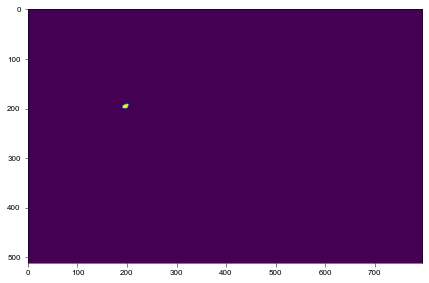

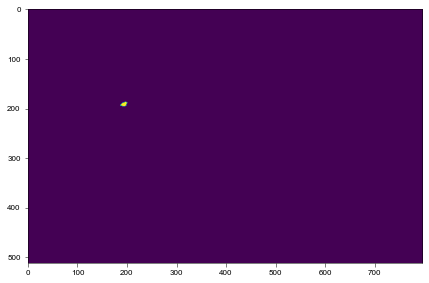

In [35]:
# This is the mask per roi that the alignment algorithm sees
# Note that for multiplane animals, FOVs of each plane get stacked 
# next to each other so they have double the number of y pixels (1592 instead of 796)
roistack = np.zeros([sess.s2p_stats.shape[0], sess.s2p_ops['Ly'], sess.s2p_ops['Lx']]).astype(np.float32)
for i, roi in enumerate(sess.s2p_stats):
    roistack[i, roi['ypix'], roi['xpix']] = 1
        
roistack2 = np.zeros([sess2.s2p_stats.shape[0], sess2.s2p_ops['Ly'], sess2.s2p_ops['Lx']]).astype(np.float32)
for i, roi in enumerate(sess2.s2p_stats):
    roistack2[i, roi['ypix'], roi['xpix']] = 1
        
plt.figure()
plt.imshow(roistack[roi_match['roi_match_inds'][0][1]['ref_inds'][0],:,:])
plt.figure()
plt.imshow(roistack2[roi_match['roi_match_inds'][0][1]['targ_inds'][0],:,:])

## Get matched ROIs for a subset of experiment days

In [83]:
# Output is shape days x cells, limited to cells tracked across all days given
# Assuming you have already saved the pickled resuls for each day

mouse = 'GCAMP15'

exp_days = [1,2]

## This is the easiest way, if you already saved the pickle for this animal:
common_rois_dict = roiAlign.find_common_rois([mouse], exp_days)
# just get the array for this mouse
common_rois = common_rois_dict[mouse]['common_rois']
common_rois[:,0:2]

1it [00:00, 17.01it/s]

multi day ROI align: using firebird path dict


array([[0, 1],
       [0, 6]])

In [81]:
# If you haven't saved the pickle, and just ran the aligner to get "roi_match" above:
inds_to_match = [0,1] #specify 0-INDEXED indices of the 'sa' class that you want to match

_common_rois = tpu.roi_matching.common_rois(sa.match_inds,inds_to_match)
_common_rois[:,0:2]

array([[0, 1],
       [0, 6]])

In [84]:
common_rois.shape

(2, 488)

## Plot ROIs of interest to spot check

You can run this if you've already saved the pickle of matched ROIs to disk.

In [85]:
from reward_relative import preprocessing as pp

exp_days = [1,2]

sess_subset = {}

for day in exp_days:
    sess_subset[day] = ut.load_sess_pickle(path_dict['preprocessed_root'],mouse,exp_day=day)

for day in exp_days:
    trial_starts =  sess_subset[day].trial_start_inds
    teleports =  sess_subset[day].teleport_inds

    # Calculate df/f
    baseline_method = 'maximin'
    #options are maximin, maxsmooth, amd maximin_concat
    F =  sess_subset[day].timeseries['F']

    Fneu =  sess_subset[day].timeseries['Fneu']
 
    dFF, events = pp.dff(F,  trial_starts, teleports,f_neu = Fneu, 
                         neuropil_method = 'subtract', 
                         baseline_method = baseline_method, 
                         neu_coef = 0.7, tau = sess_subset[day].s2p_ops['tau'], 
                         frame_rate = sess_subset[day].scan_info['frame_rate'],
                         n_planes = sess_subset[day].n_planes,
                         deconvolve = True,
                        keep_teleports = True)

    # add deltaF/F timeseries to session object
    sess_subset[day].rm_timeseries('dff')
    sess_subset[day].add_timeseries(dff=dFF, events=events) 
    sess_subset[day].add_pos_binned_trial_matrix(['dff','events'],'pos',
                                    bin_size=10, 
                                    min_pos = 0,
                                    max_pos=450
                                    )
    

/data/2P/sess/GCAMP15/25_03_2024/Env1_LocationA_002_001.pickle
/data/2P/sess/GCAMP15/26_03_2024/Env1_LocationA_002_003.pickle
baseline method = maximin
keeping teleports
No minimum subtraction
dff: (1133, 23961) min  -0.5077048424049208 max  4.351452245929819
baseline method = maximin
keeping teleports
No minimum subtraction
dff: (1045, 20859) min  -0.6602550710202499 max  4.823086918456552


In [ ]:
common_rois

1 0 0
2 0 0


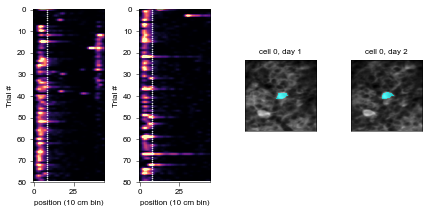

In [87]:
# pick cell of interest (COI) and plot

rrel.plotUtils.set_fig_params(fontsize=8)
from reward_relative import placeCellPlot

COI = 0 # cell of interest on the first day in the subset
col = np.where(common_rois[0,:]==COI)[0][0]

fig, ax = plt.subplots(1, common_rois.shape[0]*2, figsize=(3*common_rois.shape[0],3))

for c_i, c in enumerate(common_rois[:, col]):
    
    print(exp_days[c_i], c, col)
    ref_mat = sess_subset[exp_days[c_i]].trial_matrices['events'][0][:,:,c]
    use_norm = np.nanmean(ref_mat.ravel())
    
    targ_mat = sess_subset[exp_days[c_i]].trial_matrices['events'][0][:,:,c]
            
    norm_targ_mat = targ_mat / use_norm
            
    pf = ut.nansmooth(norm_targ_mat, 1, axis=1)

    rzone, _ = rrel.behavior.get_reward_zones(sess_subset[exp_days[c_i]])
    placeCellPlot.plot_single_cell(
                    ax[c_i],
                    trial_mat=pf,
                    vlim=[0,10],
                    reward_zone=rzone,
                    markersize=1,
                    label_axes=True,
                )

    roi_com = [sess_subset[exp_days[c_i]].s2p_stats[c]['ypix'].mean(), 
               sess_subset[exp_days[c_i]].s2p_stats[c]['xpix'].mean()]


    ybounds = [int(max(0,roi_com[0]-50)), int(min(512,roi_com[0]+50))]
    xbounds = [int(max(0,roi_com[1]-50)), int(min(796*sess.n_planes,roi_com[1]+50))]
    
    ax[c_i+common_rois.shape[0]].imshow(sess_subset[exp_days[c_i]].s2p_ops['meanImg'][ybounds[0]:ybounds[1],
                                                                xbounds[0]:xbounds[1]],cmap='Greys_r',aspect='auto')
    roi = np.zeros([512,796*sess_subset[exp_days[c_i]].n_planes])*np.nan
    roi[sess_subset[exp_days[c_i]].s2p_stats[c]['ypix'], sess_subset[exp_days[c_i]].s2p_stats[c]['xpix']]=1
    ax[c_i+common_rois.shape[0]].imshow(roi[ybounds[0]:ybounds[1],xbounds[0]:xbounds[1]],cmap='cool',alpha=.65) #bwr_r
    ax[c_i+common_rois.shape[0]].set_title(f"cell {c}, day {exp_days[c_i]}", fontsize=8)
    ax[c_i+common_rois.shape[0]].set_xticks([])
    ax[c_i+common_rois.shape[0]].set_yticks([])

    fig.patch.set_facecolor("white")
    
save_figure = False
if save_figure:
    fig_dir = rrel.utilities.make_fig_dir(path_dict)
    rrel.plotUtils.savefig(fig, fig_dir, ("%s_expdays5-8-10_TRACKED_cell_%d_pf_roi_cyan" % (
        mouse, COI)),
              extension=".pdf")